## Preliminary
### 1. Create a class for Markov Decision Processes (MDPs) that takes advantage of how you defined Markov Reward Processes

This solution can be found in src/finite_mdp.py

[[-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [100 100 100 100 100 100 100]]
S size: 95
A: {'left', 'right', 'forward'}
terminal_states: {'exit', 'crash'}

Transitions from (0,3) with 'forward': {(1, 2): 0.2, (1, 4): 0.2, (1, 1): 0.04800000000000001, (1, 5): 0.04800000000000001, (1, 3): 0.504}
Transitions from (0,3) with 'left': {(0, 1): 0.6324555320336759, (0, 2): 0.3675444679663241}
Transitions from (0,3) with 'right': {(0, 5): 0.6324555320336759, (0

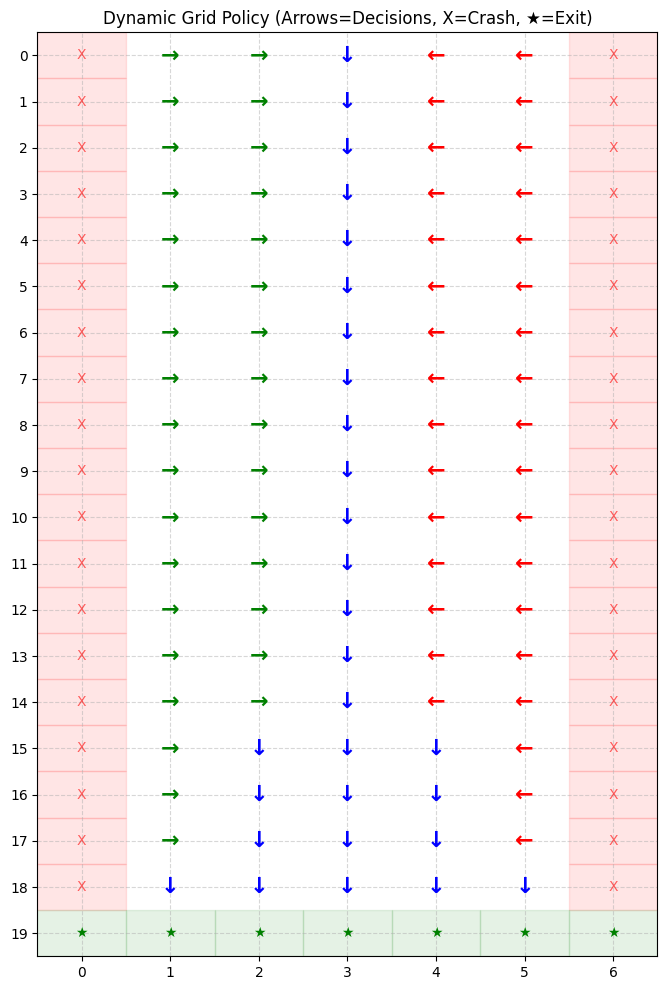

In [1]:
from src.p1.helpers import generate_grid
from src.utils.grid_environment import GridEnvironment
from src.utils.value_convergence import policy_iteration
from src.p1.helpers import visualize_policy


# Set parameters for the grid world
grid_size = (20, 7)
reward_range = [-1, -1]
terminal_state_values = [-20, 100]
gamma = 0.99
step_penalty = -1
random_transition_type = "m2p1"
random_probability = 0.4 # wind chance
start_state = (0, 3)

action_map = {
    "forward": (1, 0), 
    "left": (0, -1), 
    "right": (0, 1)
}

terminal_map = {
    "crash": -20,
    "exit": 100
}

# Generate the grid for the environment
grid = generate_grid(
    grid_size=grid_size,
    reward_range=reward_range,
)

print(grid)

# Initialize the environment
chasm_env = GridEnvironment(
    curr_grid=grid,
    reward_range=reward_range,
    terminal_state_values=terminal_state_values,
    gamma=gamma,
    step_penalty=step_penalty,
    random_transition_type=random_transition_type,
    random_probability=random_probability,
    start_state=start_state
)

# Run policy iteration
V, policy = policy_iteration(
    chasm_env.S,
    chasm_env.A,
    chasm_env,
    chasm_env.terminal_states,
    chasm_env.terminal_state_values,
    gamma=chasm_env.gamma
)

print("\nOptimal policy sample:")
for i in range(5):
    for j in range(7):
        if (i, j) in policy:
            print(f"({i},{j}): {policy[(i,j)]}", end="  ")
    print()

print(f"\nTotal states in policy: {len(policy)}")

# Count actions
action_counts = {}
for s, a in policy.items():
    if isinstance(s, tuple):
        action_counts[a] = action_counts.get(a, 0) + 1
print(f"Action distribution: {action_counts}")

visualize_policy(grid_size, policy, mask=grid)